In [3]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression

drive.mount('/content/drive')

#visual style setup
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

#load dataset
df = pd.read_csv('/content/drive/MyDrive/dataset/car_prediction_data.csv')
df.head()

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Mounted at /content/drive
Dataset Shape: (301, 9)

First 5 Rows:


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [4]:
df_fe = df.copy()

#date & time feature extraction: car age
#calculating vehicle age assuming current reference year (2026)
CURRENT_YEAR = 2026
df_fe['Car_Age'] = CURRENT_YEAR - df_fe['Year']

#text Feature Extraction: brand name
#extracting manufacturer brand from Car_Name
df_fe['Brand'] = df_fe['Car_Name'].apply(lambda x: x.split()[0].lower())

#new domain specific feature: usage rate (kms driven per year)
df_fe['Kms_Per_Year'] = df_fe['Kms_Driven'] / (df_fe['Car_Age'] + 0.1)

#price metrics: depreciation value & depreciation percentage
df_fe['Price_Depreciation'] = df_fe['Present_Price'] - df_fe['Selling_Price']
df_fe['Depreciation_Pct'] = (df_fe['Price_Depreciation'] / df_fe['Present_Price']) * 100

#log transformation for skewed numerical features
df_fe['Log_Kms_Driven'] = np.log1p(df_fe['Kms_Driven'])
df_fe['Log_Present_Price'] = np.log1p(df_fe['Present_Price'])

print("Feature Engineering Completed. New Dataset Shape:", df_fe.shape)
display(df_fe[['Car_Name', 'Brand', 'Car_Age', 'Kms_Per_Year', 'Price_Depreciation', 'Depreciation_Pct']].head())

Feature Engineering Completed. New Dataset Shape: (301, 16)


,Car_Name,Brand,Car_Age,Kms_Per_Year,Price_Depreciation,Depreciation_Pct
0,ritz,ritz,12,2231.404959,2.24,40.071556
1,sx4,sx4,13,3282.442748,4.79,50.209644
2,ciaz,ciaz,9,758.241758,2.60,26.395939
3,wagon r,wagon,15,344.370861,1.30,31.325301
4,swift,swift,12,3508.264463,2.27,33.042213


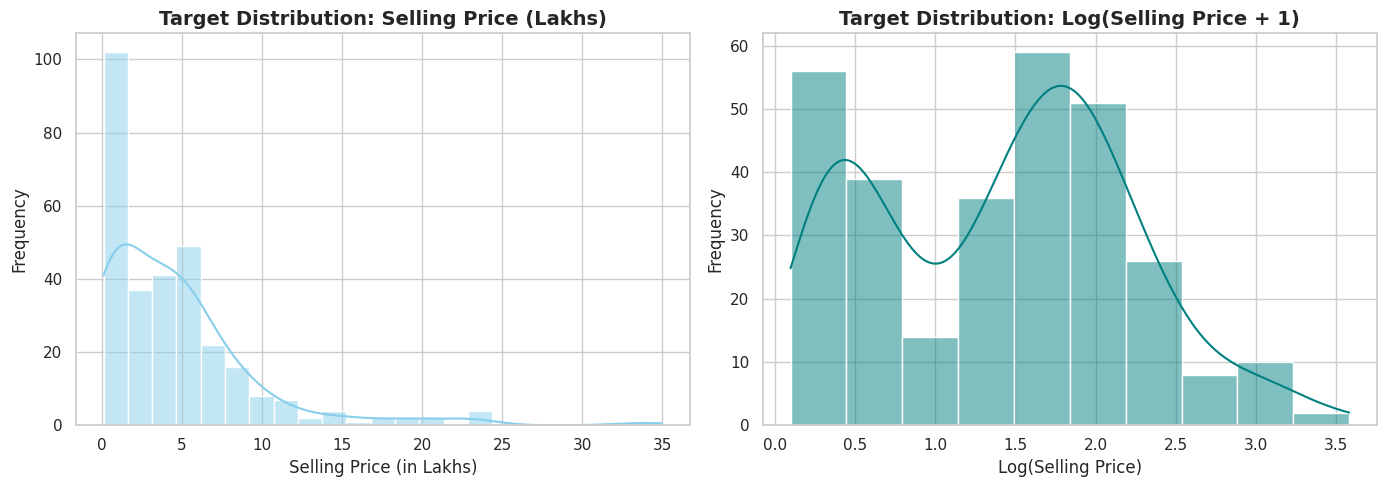

Skewness of Selling Price: 2.493422417797524
Skewness of Log Selling Price: 0.115141322922288


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw Selling Price
sns.histplot(df_fe['Selling_Price'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Target Distribution: Selling Price (Lakhs)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Selling Price (in Lakhs)')
axes[0].set_ylabel('Frequency')

#log-transformed Selling Price
sns.histplot(np.log1p(df_fe['Selling_Price']), kde=True, color='teal', ax=axes[1])
axes[1].set_title('Target Distribution: Log(Selling Price + 1)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log(Selling Price)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Skewness of Selling Price:", df_fe['Selling_Price'].skew())
print("Skewness of Log Selling Price:", np.log1p(df_fe['Selling_Price']).skew())

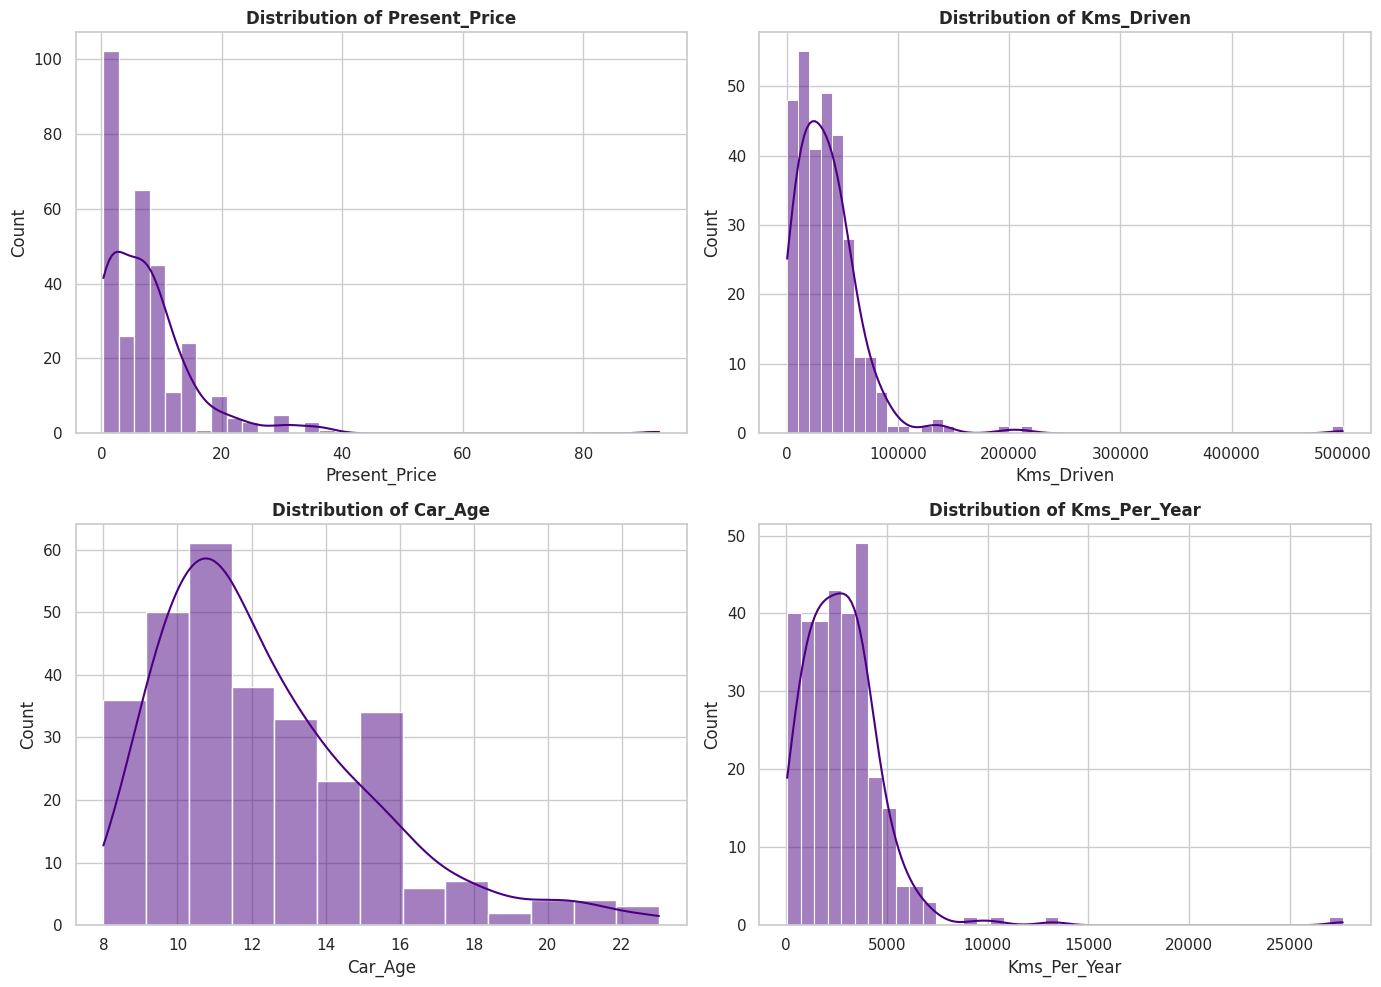

In [6]:
num_cols = ['Present_Price', 'Kms_Driven', 'Car_Age', 'Kms_Per_Year']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df_fe[col], kde=True, color='indigo', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

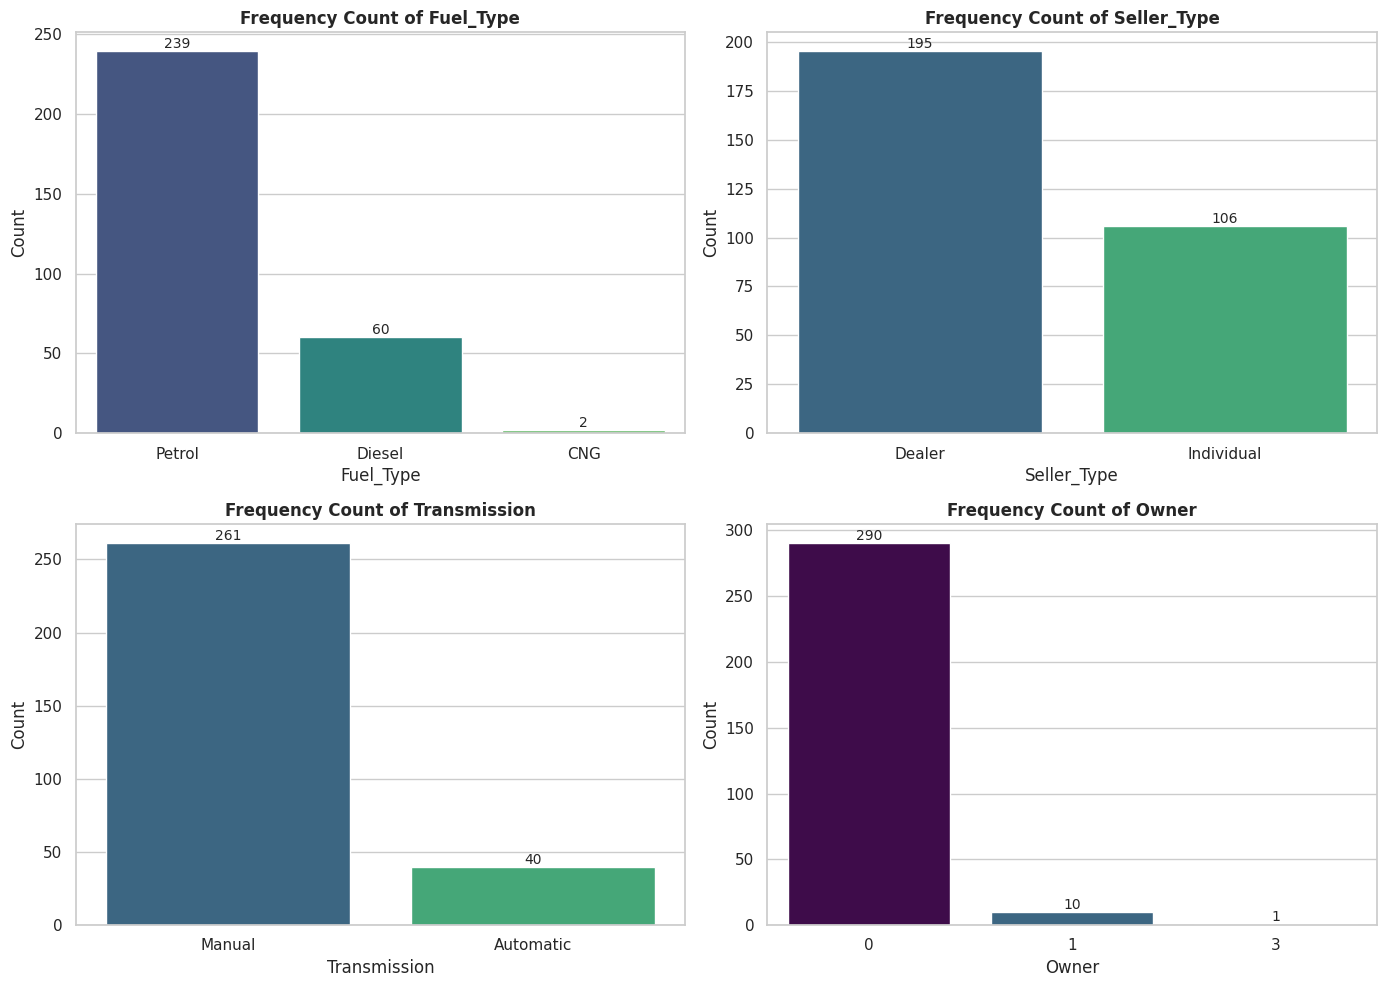

In [7]:
cat_cols = ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df_fe, x=col, palette='viridis', ax=axes[i], hue=col, legend=False)
    axes[i].set_title(f'Frequency Count of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

    #add count annotations
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height())}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

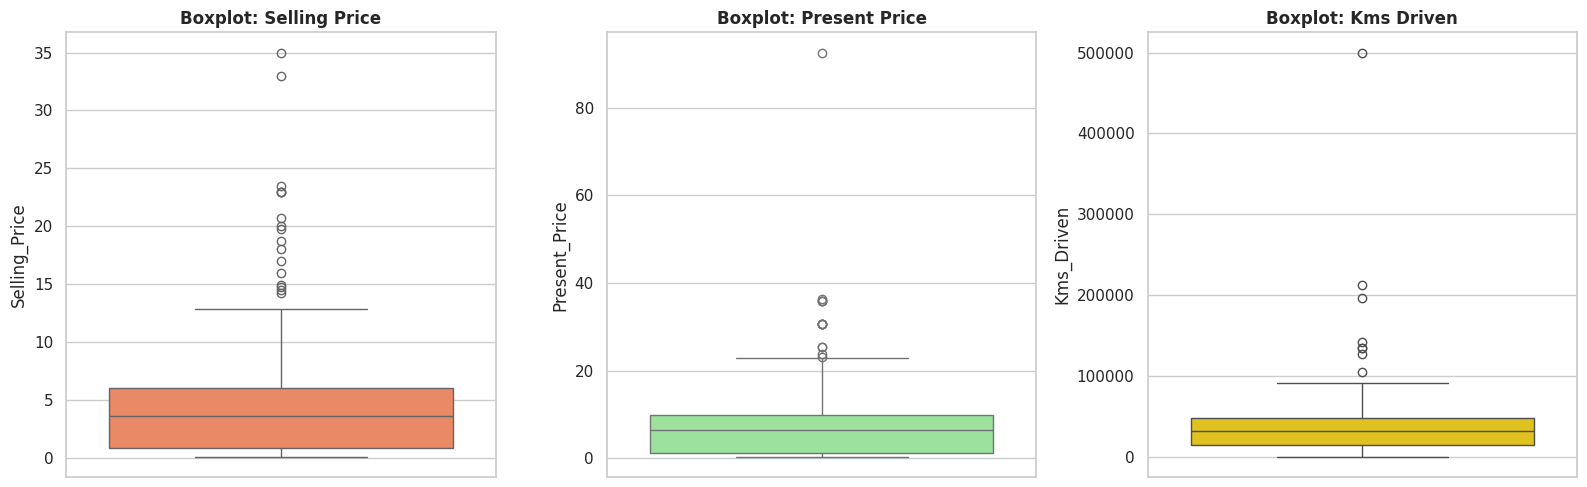

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df_fe, y='Selling_Price', ax=axes[0], color='coral')
axes[0].set_title('Boxplot: Selling Price', fontsize=12, fontweight='bold')

sns.boxplot(data=df_fe, y='Present_Price', ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot: Present Price', fontsize=12, fontweight='bold')

sns.boxplot(data=df_fe, y='Kms_Driven', ax=axes[2], color='gold')
axes[2].set_title('Boxplot: Kms Driven', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

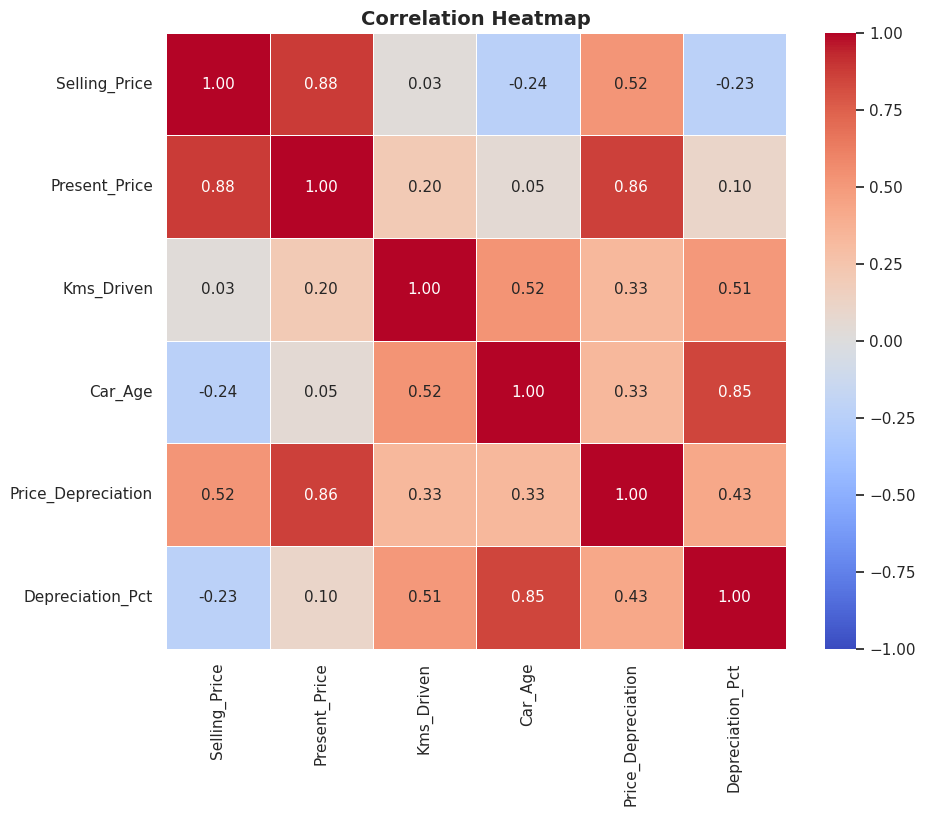

In [9]:
plt.figure(figsize=(10, 8))

#select numerical columns for correlation calculation
corr_matrix = df_fe[['Selling_Price', 'Present_Price', 'Kms_Driven', 'Car_Age', 'Price_Depreciation', 'Depreciation_Pct']].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

/tmp/ipykernel_1414/1635811970.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_fe, x='Fuel_Type', y='Selling_Price', palette='Set2', ax=axes[0], errorbar=None)
/tmp/ipykernel_1414/1635811970.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_fe, x='Seller_Type', y='Selling_Price', palette='Set2', ax=axes[1], errorbar=None)
/tmp/ipykernel_1414/1635811970.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_fe, x='Transmission', y='Selling_Price', palette='Set2', ax=axes[2], errorbar=None)


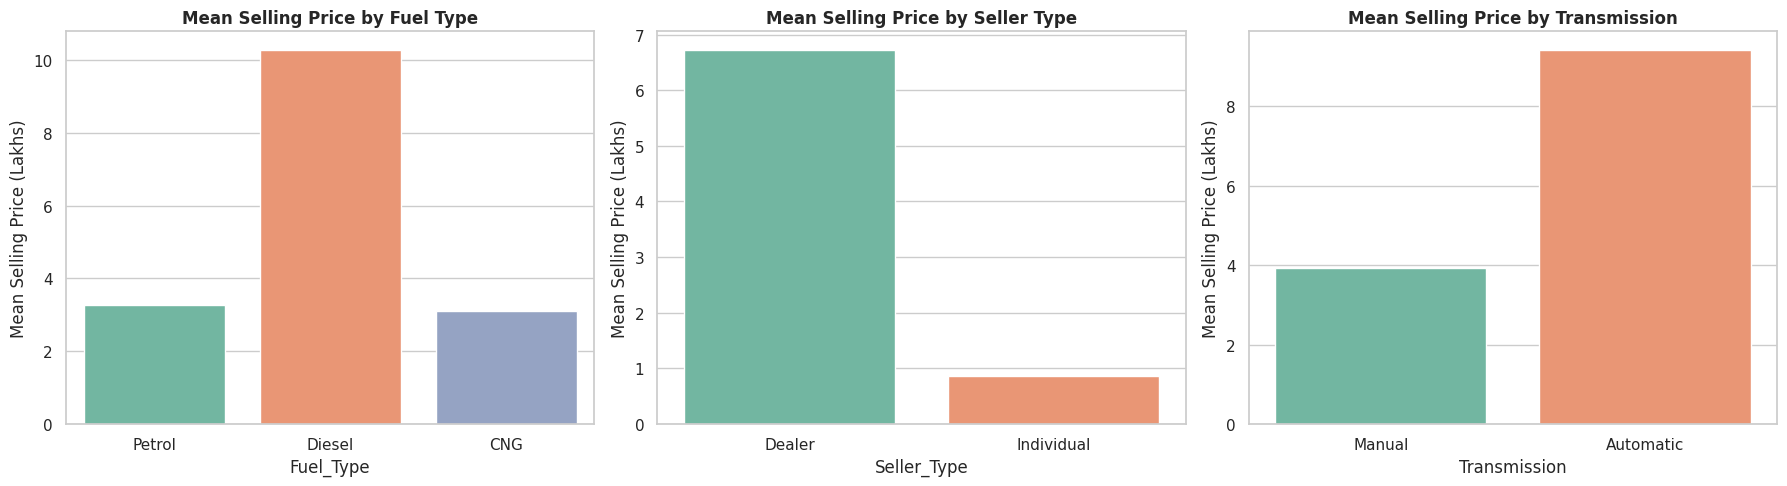

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=df_fe, x='Fuel_Type', y='Selling_Price', palette='Set2', ax=axes[0], errorbar=None)
axes[0].set_title('Mean Selling Price by Fuel Type', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Mean Selling Price (Lakhs)')

sns.barplot(data=df_fe, x='Seller_Type', y='Selling_Price', palette='Set2', ax=axes[1], errorbar=None)
axes[1].set_title('Mean Selling Price by Seller Type', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Mean Selling Price (Lakhs)')

sns.barplot(data=df_fe, x='Transmission', y='Selling_Price', palette='Set2', ax=axes[2], errorbar=None)
axes[2].set_title('Mean Selling Price by Transmission', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Mean Selling Price (Lakhs)')

plt.tight_layout()
plt.show()

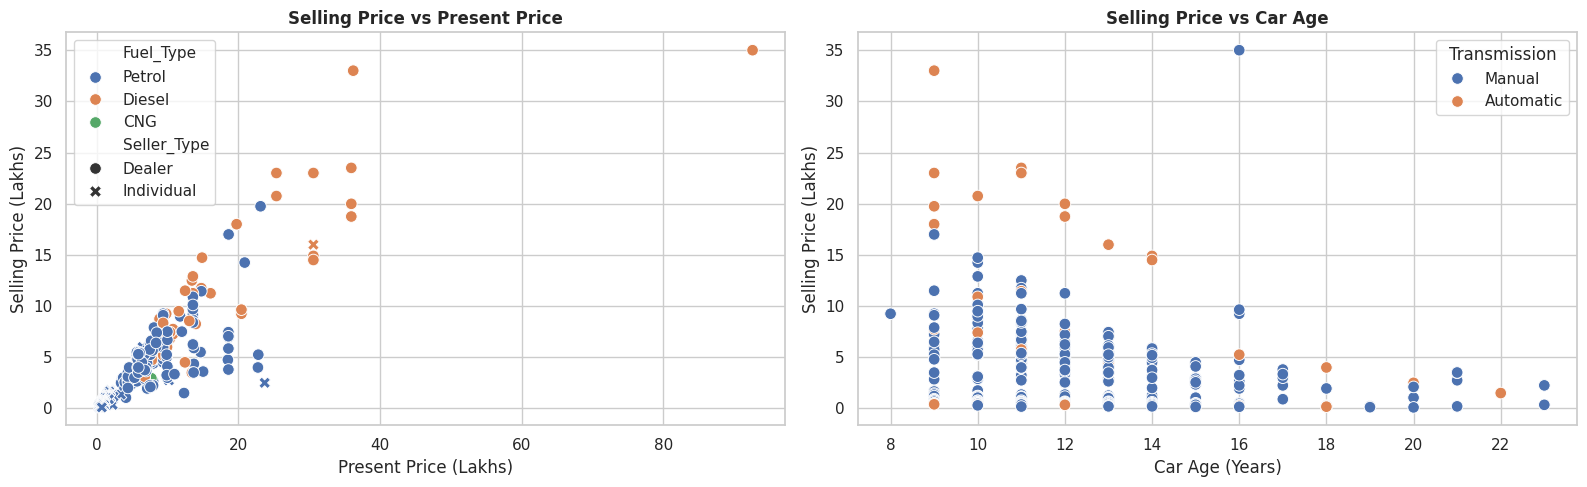

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.scatterplot(data=df_fe, x='Present_Price', y='Selling_Price', hue='Fuel_Type', style='Seller_Type', s=70, ax=axes[0])
axes[0].set_title('Selling Price vs Present Price', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Present Price (Lakhs)')
axes[0].set_ylabel('Selling Price (Lakhs)')

sns.scatterplot(data=df_fe, x='Car_Age', y='Selling_Price', hue='Transmission', s=70, ax=axes[1])
axes[1].set_title('Selling Price vs Car Age', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Car Age (Years)')
axes[1].set_ylabel('Selling Price (Lakhs)')

plt.tight_layout()
plt.show()

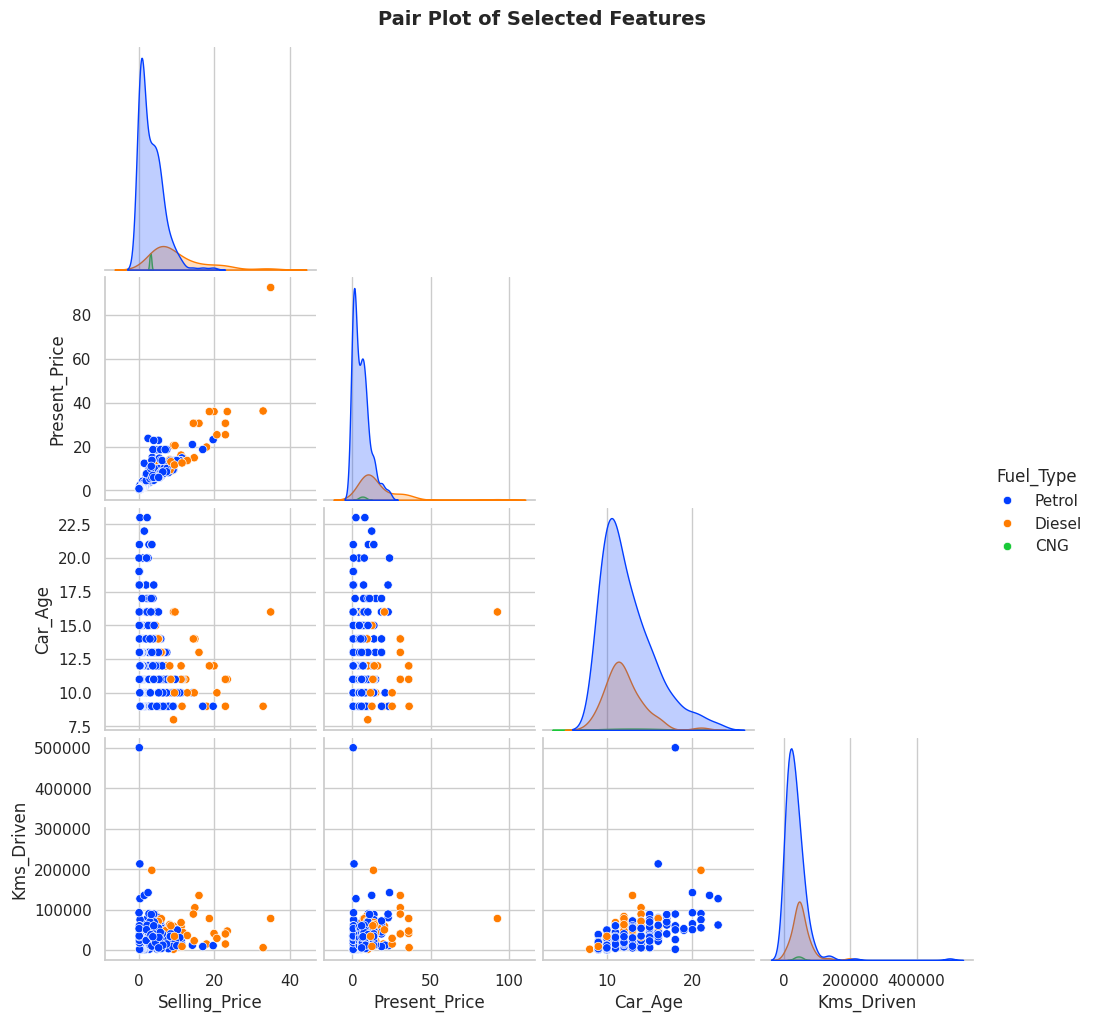

In [12]:
selected_features = ['Selling_Price', 'Present_Price', 'Car_Age', 'Kms_Driven', 'Fuel_Type']
sns.pairplot(df_fe[selected_features], hue='Fuel_Type', palette='bright', corner=True)
plt.suptitle('Pair Plot of Selected Features', y=1.02, fontsize=14, fontweight='bold')
plt.show()

/tmp/ipykernel_1414/2156727638.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='crest')


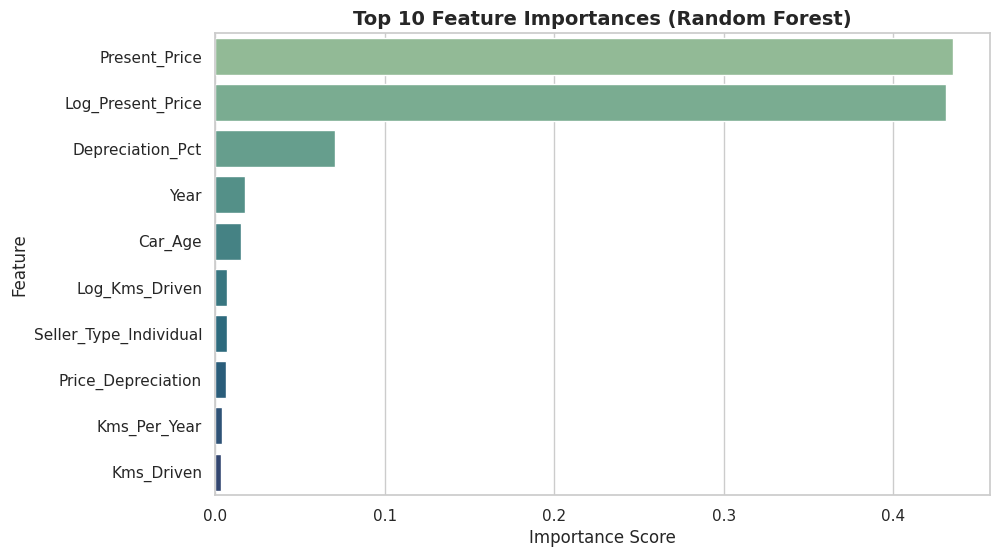

In [13]:
df_model = pd.get_dummies(df_fe.drop(columns=['Car_Name', 'Brand']), drop_first=True)

X = df_model.drop(columns=['Selling_Price'])
y = df_model['Selling_Price']

#fit random forest regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

#extract and plot feature importances
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='crest')
plt.title('Top 10 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()